In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report

In [4]:
df = pd.read_csv("/content/heart_disease_health_indicators_BRFSS2015.csv")

In [5]:
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128681 entries, 0 to 128680
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  128681 non-null  float64
 1   HighBP                128681 non-null  float64
 2   HighChol              128681 non-null  float64
 3   CholCheck             128681 non-null  float64
 4   BMI                   128681 non-null  float64
 5   Smoker                128681 non-null  float64
 6   Stroke                128681 non-null  float64
 7   Diabetes              128681 non-null  float64
 8   PhysActivity          128681 non-null  float64
 9   Fruits                128681 non-null  float64
 10  Veggies               128681 non-null  float64
 11  HvyAlcoholConsump     128681 non-null  float64
 12  AnyHealthcare         128681 non-null  float64
 13  NoDocbcCost           128681 non-null  float64
 14  GenHlth               128681 non-null  float64
 15  

In [5]:
df.describe()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.094186,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.296921,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.292087,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.698160,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [6]:
df.nunique()

,0
HeartDiseaseorAttack,2
HighBP,2
HighChol,2
CholCheck,2
BMI,84
Smoker,2
Stroke,2
Diabetes,3
PhysActivity,2
Fruits,2


In [7]:
#Handling Missing Values
df.isnull().sum()


,0
HeartDiseaseorAttack,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
Diabetes,0
PhysActivity,0
Fruits,0


In [8]:
# duplicates
print("Duplicates:", df.duplicated().sum())
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Dropped duplicates, new shape:", df.shape)


Duplicates: 9009
Dropped duplicates, new shape: (119672, 22)


In [9]:
# binary columns
binary_cols = [
    'HeartDiseaseorAttack','HighBP','HighChol','CholCheck','Smoker',
    'Stroke','Diabetes','PhysActivity','Fruits','Veggies',
    'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex'
]

df[binary_cols] = df[binary_cols].astype(int)

# cap BMI outliers
df['BMI'] = df['BMI'].clip(lower=12, upper=60)

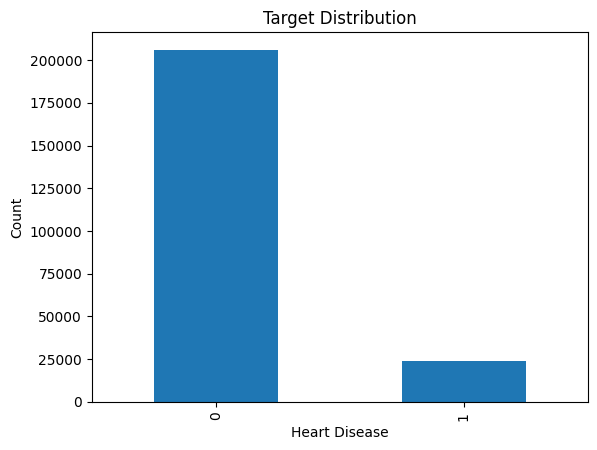

In [10]:
#visualization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('HeartDiseaseorAttack', axis=1)
y = df['HeartDiseaseorAttack']

plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()


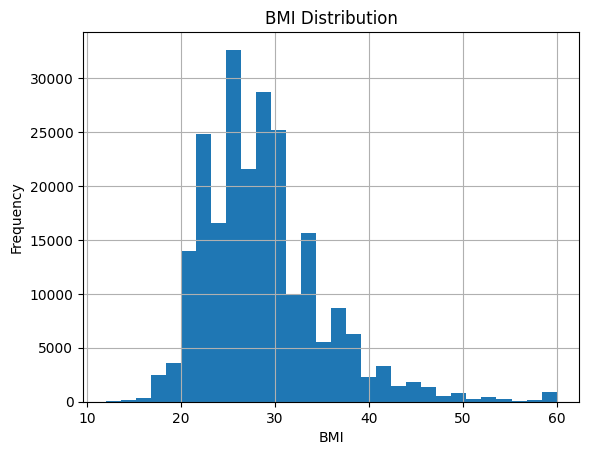

In [11]:
plt.figure()
df['BMI'].hist(bins=30)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()


<Figure size 640x480 with 0 Axes>

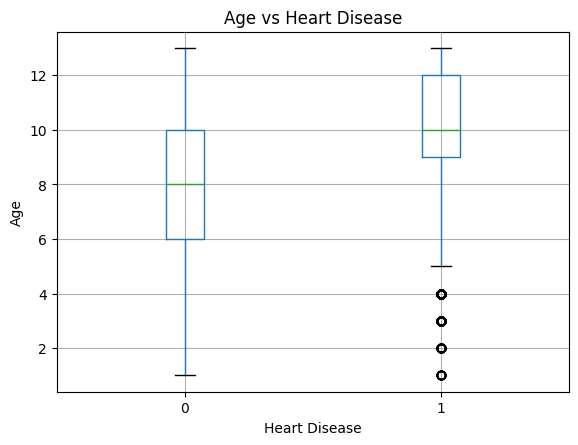

In [12]:
plt.figure()
df.boxplot(column='Age', by='HeartDiseaseorAttack')
plt.title("Age vs Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()


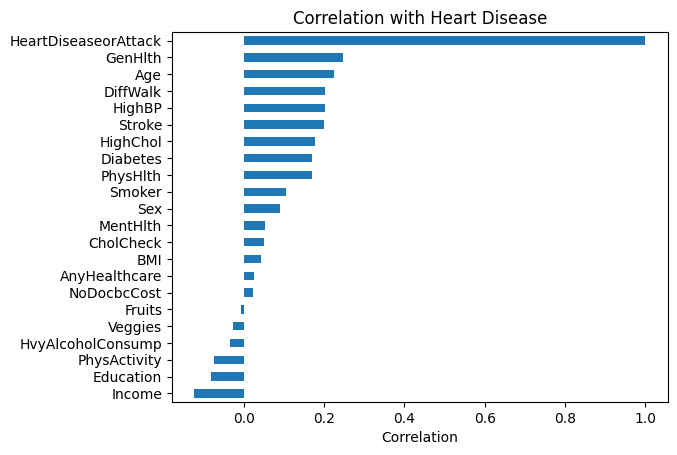

In [13]:
corr = df.corr()['HeartDiseaseorAttack'].sort_values()

plt.figure()
corr.plot(kind='barh')
plt.title("Correlation with Heart Disease")
plt.xlabel("Correlation")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


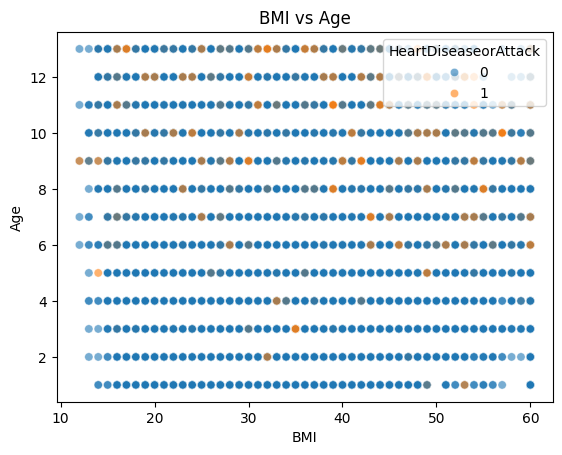

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.scatterplot(
    data=df,
    x='BMI',
    y='Age',
    hue='HeartDiseaseorAttack',
    alpha=0.6
)
plt.title("BMI vs Age")
plt.show()


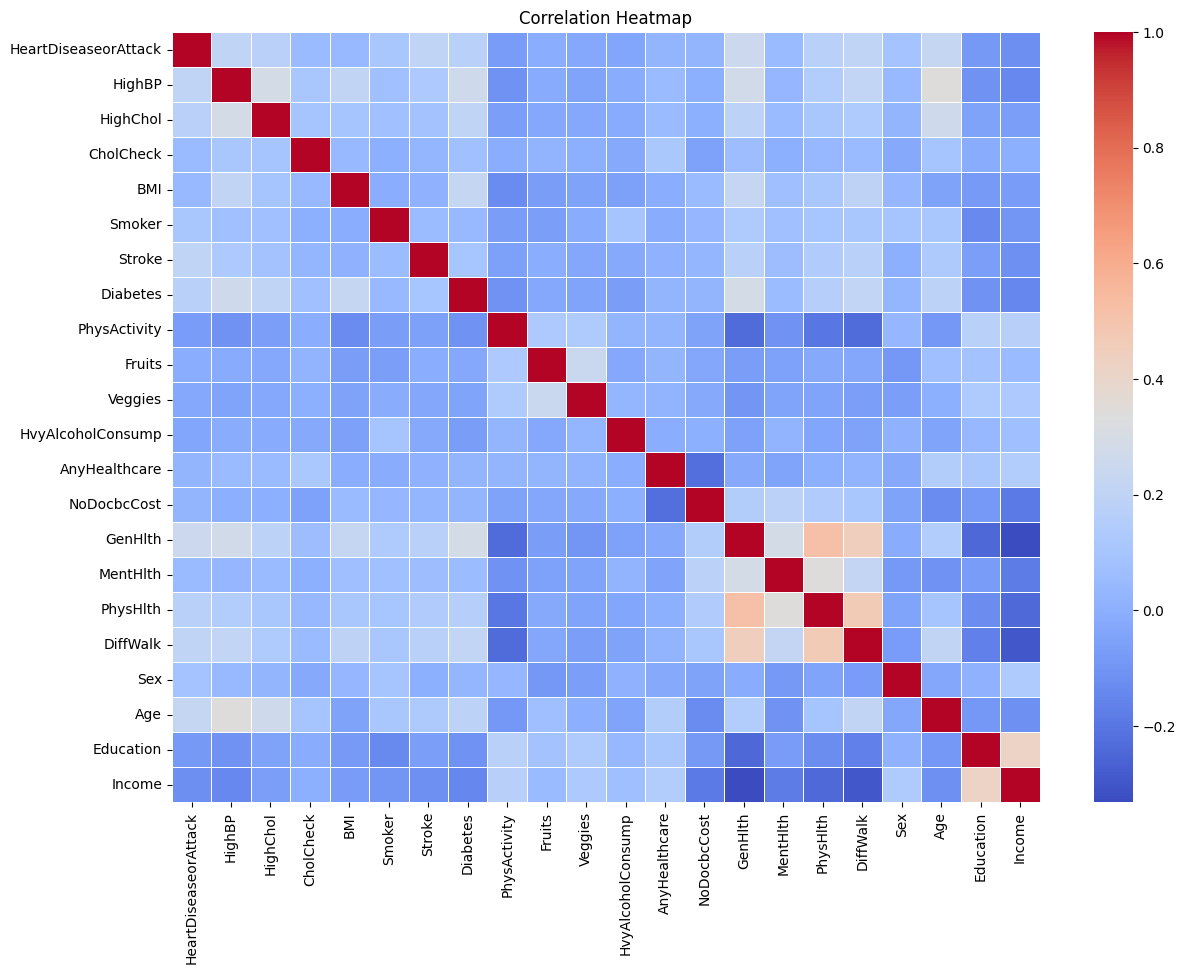

In [15]:
plt.figure(figsize=(14,10))
corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


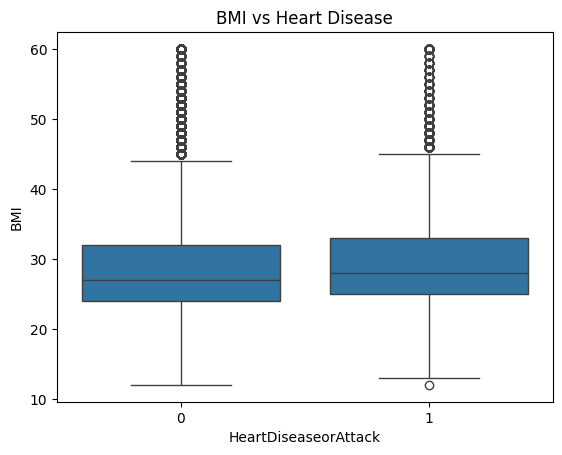

In [16]:
plt.figure()
sns.boxplot(
    data=df,
    x='HeartDiseaseorAttack',
    y='BMI'
)
plt.title("BMI vs Heart Disease")
plt.show()


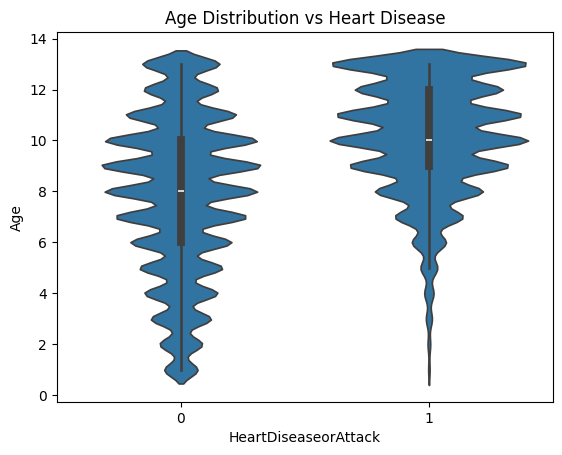

In [17]:
plt.figure()
sns.violinplot(
    data=df,
    x='HeartDiseaseorAttack',
    y='Age'
)
plt.title("Age Distribution vs Heart Disease")
plt.show()


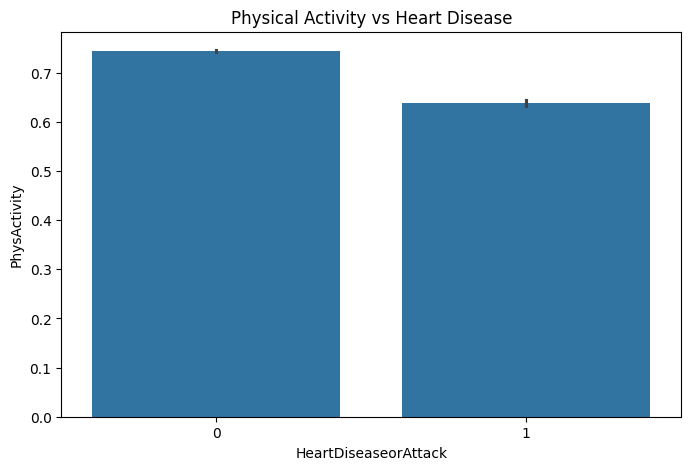

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='HeartDiseaseorAttack',
    y='PhysActivity'
)
plt.title("Physical Activity vs Heart Disease")
plt.show()


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
lr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])


In [12]:
#Scaling &split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

X = df.drop('HeartDiseaseorAttack', axis=1)
y = df['HeartDiseaseorAttack']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score


In [16]:
lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)
LR_Accuracy=accuracy_score(y_test, lr_pred)
LR_F1=f1_score(y_test, lr_pred)
print("LR Accuracy:",LR_Accuracy )
print("LR F1:",LR_F1 )


LR Accuracy: 0.9021516607478588
LR F1: 0.20122783083219645


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=10, random_state=42)

In [21]:
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("Accuracy:", acc_rf)
print("F1-score:", f1_rf)


Random Forest
Accuracy: 0.8162523501148945
F1-score: 0.39270919635459817


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [23]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8543 - loss: nan - val_accuracy: 0.8999 - val_loss: nan
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9010 - loss: nan - val_accuracy: 0.8999 - val_loss: nan
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8994 - loss: nan - val_accuracy: 0.8999 - val_loss: nan
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8998 - loss: nan - val_accuracy: 0.8999 - val_loss: nan
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.8999 - val_loss: nan
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8985 - loss: nan - val_accuracy: 0.8999 - val_loss: nan
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9004 - loss: nan - val_accuracy: 0.8999 - val_loss: nan
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8992 - loss: nan - val_accuracy: 0.8999 - val_loss: nan
Epoch 9/20
300/300 ━━━━

In [24]:
dl_loss, dl_acc = model.evaluate(X_test, y_test)
print("DL Accuracy:", dl_acc)


748/748 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9051 - loss: nan
DL Accuracy: 0.8999791145324707


In [25]:
y_prob_dl = model.predict(X_test)


748/748 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [28]:
y_pred_dl = (y_prob_dl >= 0.1).astype(int)
from sklearn.metrics import f1_score

f1_dl = f1_score(y_test, y_pred_dl)
print("DL F1-score:", f1_dl)


DL F1-score: 0.0


In [30]:
import joblib

joblib.dump(lr_pipeline, "best_lr_pipeline.pkl")
print("Logistic Regression pipeline saved successfully ✅")


Logistic Regression pipeline saved successfully ✅
